In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [52]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202)
Xb ,yb = make_blobs(n_samples=2502, random_state=259202, n_features=2, centers=5, cluster_std=0.8)

In [53]:
X.shape, y.shape, Xm.shape, ym.shape, Xb.shape, yb.shape

((2502, 2), (2502,), (2502, 2), (2502,), (2502, 2), (2502,))

In [54]:
print(set(yb))
yb = np.where(yb < 3, 0, 1)
print(set(yb))

{0, 1, 2, 3, 4}
{0, 1}


In [55]:
def plot_data(X,y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

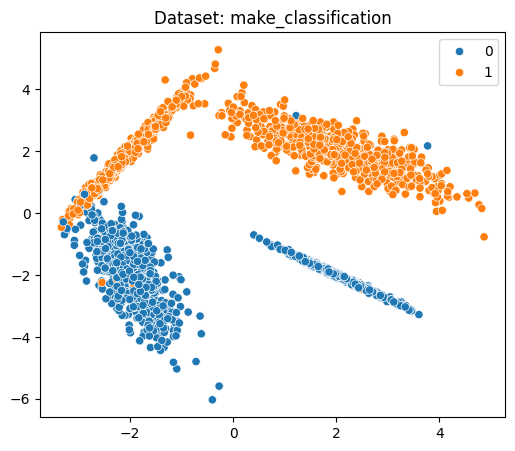

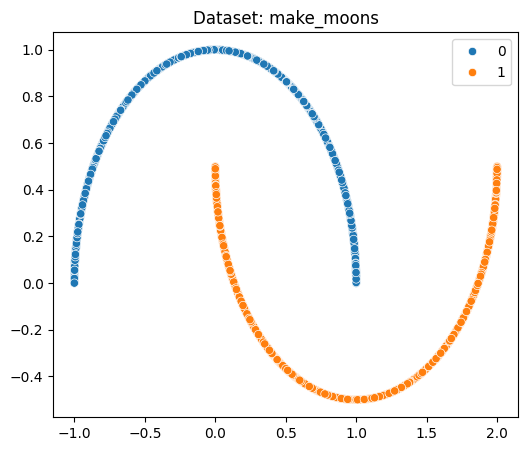

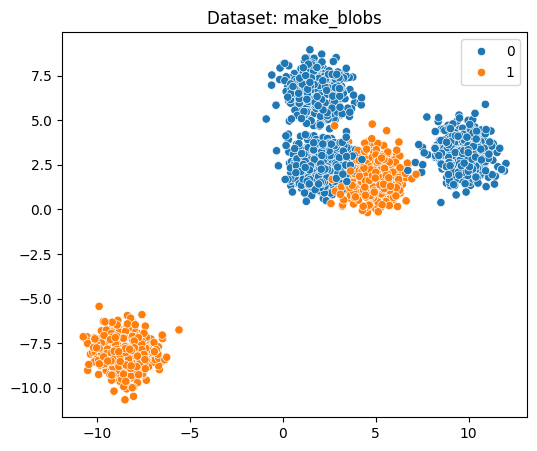

In [56]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")
plot_data(Xb,yb,"Dataset: make_blobs")

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, random_state=295202)

In [58]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    # reshape the result back into the grid
    Z = Z.reshape(xx.shape)

    # plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # plot decision line boundary
    plt.contour(xx, yy, Z, colors='k', linewidths=1)
    
    # data points
    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    
    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

In [59]:
cm_df = []
roc_df = []

# Implemented Decision Tree Classifier

No need for normalization - there are ifs.

In [60]:
class TreeNode:
    """Node of a decision tree"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None,*, value=None, distribution=None):
        self.feature_idx = feature_idx # index of the feature to split on
        self.threshold = threshold # threshold value to split on
        self.left = left # left child node
        self.right = right # right child node
        self.value = value # class label if leaf node, the * is forcing the use of keyword arguments for value
        self.distribution = distribution
        
    def is_leaf(self):
        return self.value is not None

In [61]:
class DecisionTree:
    """Decision Tree Classifier with entropy"""
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None
    
    def fit(self, X, y):
        self.root = self._grow_tree(X,y, depth=0)
        return self
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth) or n_labels == 1:
            leaf_value = self._most_common_label(y)
            
            hist = np.bincount(y, minlength=max(y)+1)
            distribution = hist / len(y)
        
            return TreeNode(value=leaf_value, distribution=distribution)
        
        # find best split
        best_feature, best_thresh = self._best_split(X, y, n_features)
        
        # handle edge case - no split found
        if best_feature is None or best_thresh is None:
            leaf_value = self._most_common_label(y)
            
            hist = np.bincount(y, minlength=max(y)+1)
            distribution = hist / len(y)
            
            return TreeNode(value=leaf_value, distribution=distribution)
        
        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature] ,best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        
        return TreeNode(best_feature, best_thresh, left, right)
        
    def _best_split(self, X, y, n_features):
        best_gain = -1
        split_idx, split_thrs = None, None
        
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            values = np.unique(X_column)
            if len(values) > 50: # for too many unique values, we can use a threshold
                thresholds = np.linspace(values.min(), values.max(), 50)
            else:
                thresholds = values
            
            for thr in thresholds:
                # calculate IG
                gain = self._information_gain(y, X_column, thr)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thrs = thr
                    
        return split_idx, split_thrs
    
    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)
        
        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # calculate the weighted avg entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r        
        
        # calculate IG
        information_gain = parent_entropy - child_entropy
        
        return information_gain
        
    def _split(self, X_column, split_threshold):
        left_idxs = np.argwhere(X_column <= split_threshold).flatten()
        right_idxs = np.argwhere(X_column > split_threshold).flatten()
        return left_idxs, right_idxs
        
    def _entropy(self, y):
        # np.bincount([1,2,3,1,2]) -> [0, 2, 2, 1]
        hist = np.bincount(y) # on each index is the count of the index value in y
        ps = hist / len(y) # p(x)
        return -np.sum([ p * np.log(p) if p > 0 else 0 for p in ps ])
        
        
    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict_proba(self, X):
        n_samples = X.shape[0]
        
        leaf_values = self._get_all_leaf_values(self.root)
        n_classes = max(leaf_values) + 1
        
        proba = np.zeros((n_samples, n_classes))
        
        for i, x in enumerate(X):
            # Find the leaf node for each sample
            node = self._traverse_tree_to_leaf(x, self.root)
            # Get the distribution of classes at the leaf node
            if len(node.distribution) <= n_classes: # if there are less classes than all classes
                proba[i, :len(node.distribution)] = node.distribution
            else:
                proba[i, :] = node.distribution[:n_classes]
        
        return proba
    
    def _get_all_leaf_values(self, node):
        if node.is_leaf():
            return [node.value]
        
        left_values = self._get_all_leaf_values(node.left)
        right_values = self._get_all_leaf_values(node.right)
        
        return left_values + right_values
    
    def _traverse_tree_to_leaf(self, x, node):
        if node.is_leaf():
            return node
        
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree_to_leaf(x, node.left)
        return self._traverse_tree_to_leaf(x, node.right)

In [62]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

all_results = []
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():

    n_features = X_tr.shape[1]
    if ds_name == 'blobs':
        n_clusters = 5
        depths = [None, n_features, n_clusters]
    else:
        depths = [None, n_features]
    
    for depth in set(depths):
        clf = DecisionTree(max_depth=depth)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        
        all_results.append({
            'dataset': ds_name,
            'depth': depth,
            'accuracy': acc,
            'model': clf
        })
        cm_df.append({
            'type': 'Implemented',
            'dataset': ds_name,
            'depth': depth,
            'y_true': y_te,
            'y_pred': y_pred
        })
        roc_df.append({
            'type': 'Implemented',
            'dataset': ds_name,
            'depth': depth,
            'y_true': y_te,
            'y_score': clf.predict_proba(X_te)
        })
        

results_impl_df = pd.DataFrame(all_results)

In [63]:
results_impl_df

,dataset,depth,accuracy,model
0,classification,NaN,0.971246,<__main__.DecisionTree object at 0x0000023E84A...
1,classification,2.0,0.992013,<__main__.DecisionTree object at 0x0000023E848...
2,moons,NaN,1.000000,<__main__.DecisionTree object at 0x0000023E849...
3,moons,2.0,0.816294,<__main__.DecisionTree object at 0x0000023E849...
4,blobs,NaN,0.969649,<__main__.DecisionTree object at 0x0000023E849...
5,blobs,2.0,0.838658,<__main__.DecisionTree object at 0x0000023E848...
6,blobs,5.0,0.980831,<__main__.DecisionTree object at 0x0000023E848...


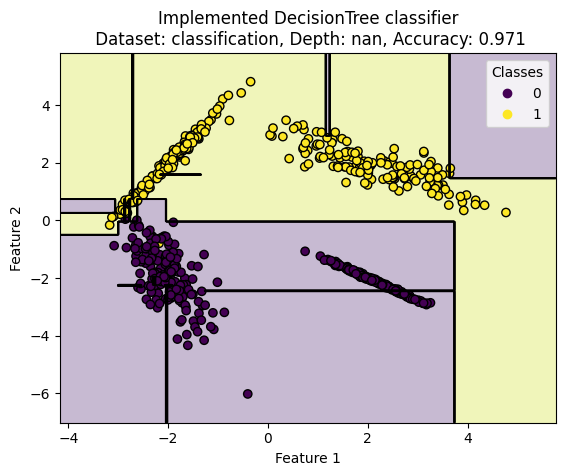

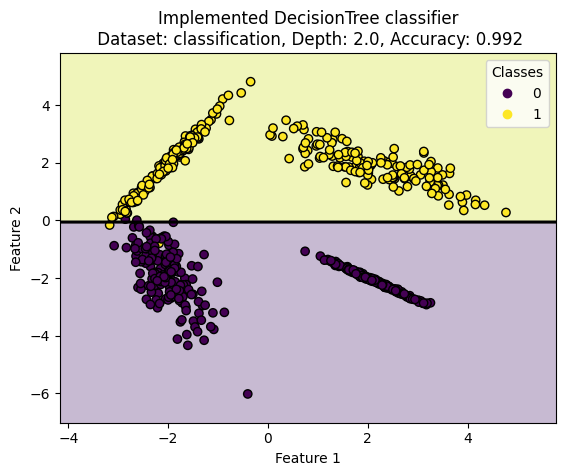

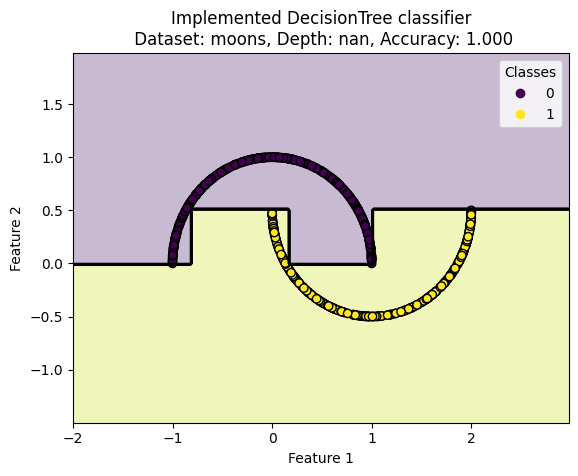

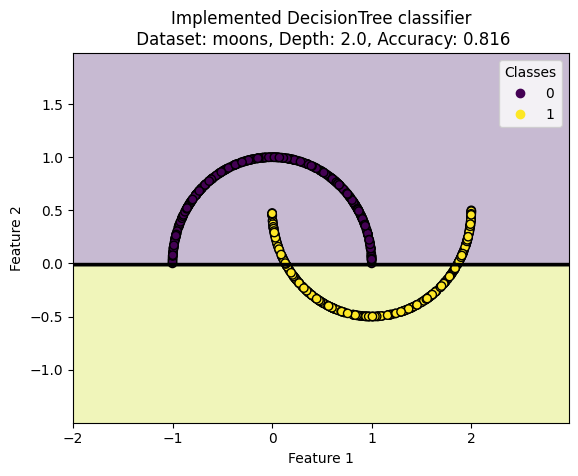

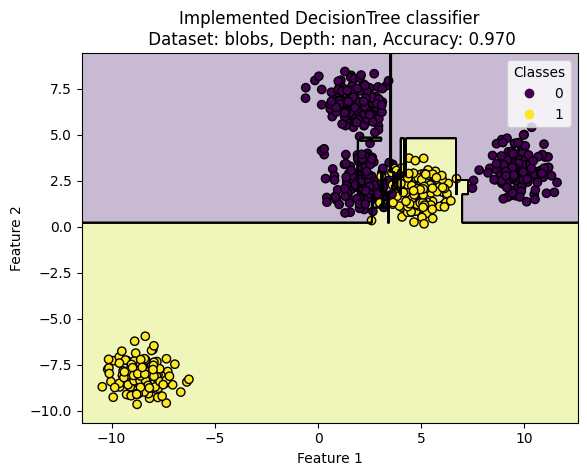

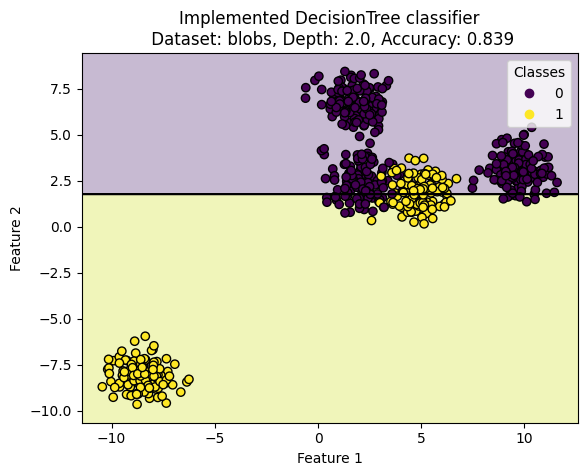

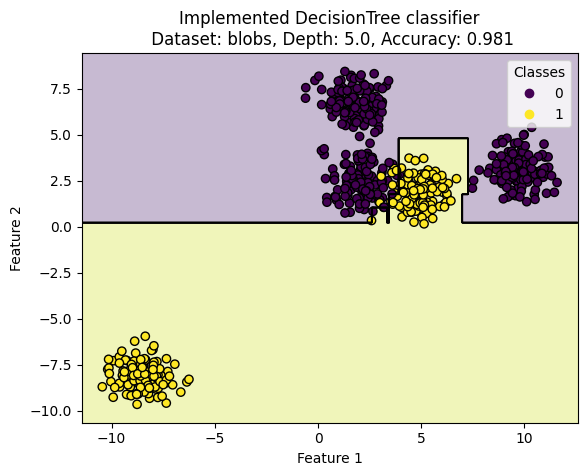

In [64]:
for _, result in results_impl_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_te, y_te = datasets[ds_name]
    
    title = f"Implemented DecisionTree classifier\n Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    plot_decision_boundary(X_te, y_te, model, title=title)

# Sklearn DecisionTreeClassifier

In [65]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

all_results = []
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():

    n_features = X_tr.shape[1]
    if ds_name == 'blobs':
        n_clusters = 5
        depths = [None, n_features, n_clusters]
    else:
        depths = [None, n_features]
    
    for depth in set(depths):
        clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth)
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_te, y_pred)
        
        all_results.append({
            'dataset': ds_name,
            'depth': depth,
            'accuracy': acc,
            'model': clf
        })
        cm_df.append({
            'type': 'Sklearn',
            'dataset': ds_name,
            'depth': depth,
            'y_true': y_te,
            'y_pred': y_pred,
        })
        roc_df.append({
            'type': 'Sklearn',
            'dataset': ds_name,
            'depth': depth,
            'y_true': y_te,
            'y_score': clf.predict_proba(X_te)[:, 1],
        })

results_df = pd.DataFrame(all_results)

In [66]:
results_df

,dataset,depth,accuracy,model
0,classification,NaN,0.977636,DecisionTreeClassifier(criterion='entropy')
1,classification,2.0,0.993610,"DecisionTreeClassifier(criterion='entropy', ma..."
2,moons,NaN,0.996805,DecisionTreeClassifier(criterion='entropy')
3,moons,2.0,0.816294,"DecisionTreeClassifier(criterion='entropy', ma..."
4,blobs,NaN,0.971246,DecisionTreeClassifier(criterion='entropy')
5,blobs,2.0,0.832268,"DecisionTreeClassifier(criterion='entropy', ma..."
6,blobs,5.0,0.982428,"DecisionTreeClassifier(criterion='entropy', ma..."


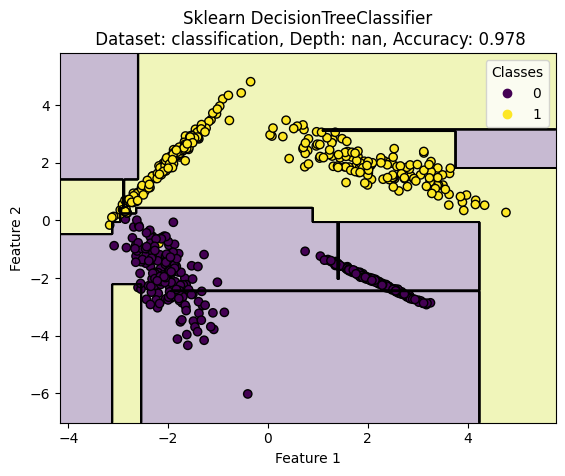

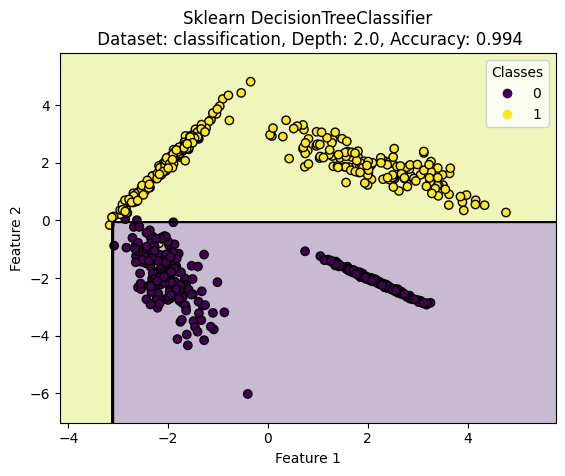

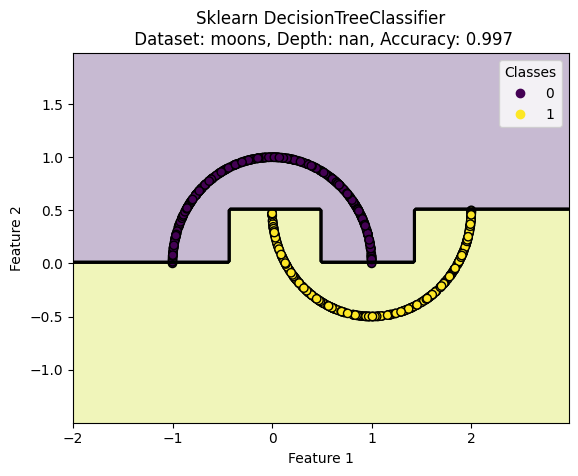

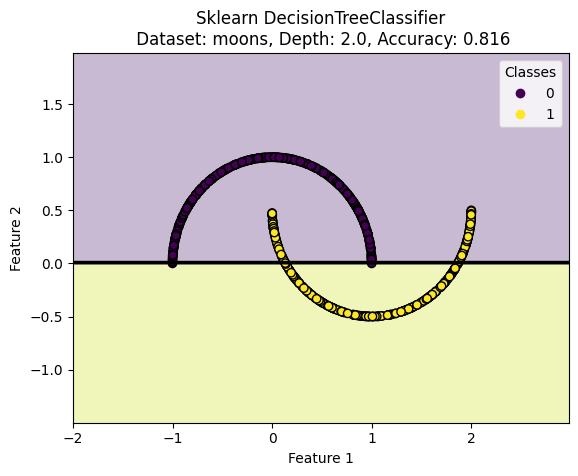

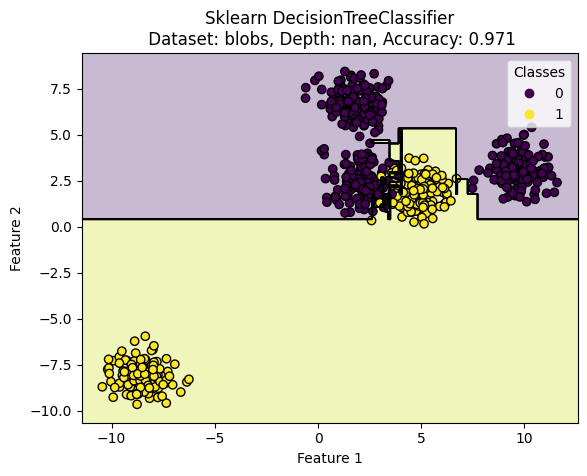

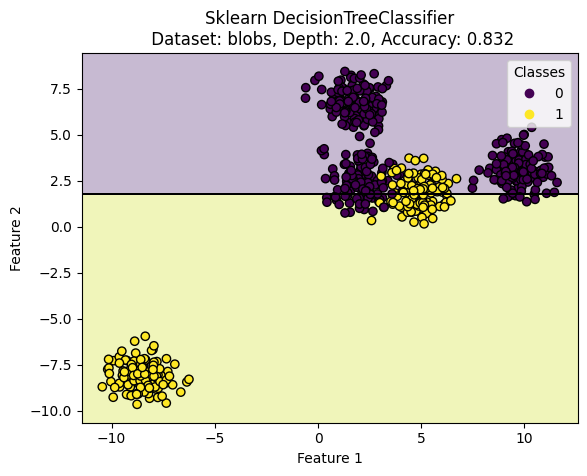

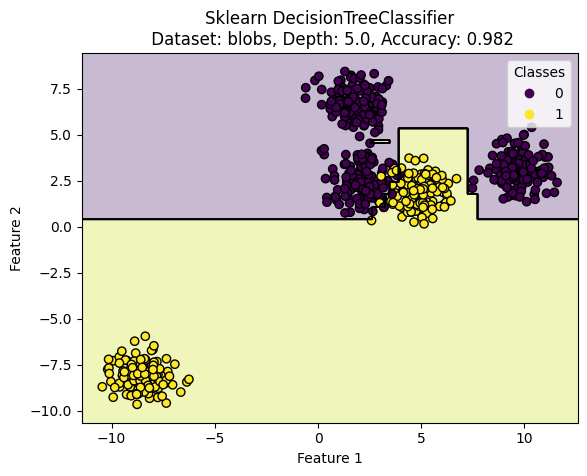

In [67]:
for _, result in results_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_te, y_te = datasets[ds_name]
    
    title = f"Sklearn DecisionTreeClassifier\n Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    plot_decision_boundary(X_te, y_te, model, title=title)

# Evaluation

In [68]:
results_impl_df

,dataset,depth,accuracy,model
0,classification,NaN,0.971246,<__main__.DecisionTree object at 0x0000023E84A...
1,classification,2.0,0.992013,<__main__.DecisionTree object at 0x0000023E848...
2,moons,NaN,1.000000,<__main__.DecisionTree object at 0x0000023E849...
3,moons,2.0,0.816294,<__main__.DecisionTree object at 0x0000023E849...
4,blobs,NaN,0.969649,<__main__.DecisionTree object at 0x0000023E849...
5,blobs,2.0,0.838658,<__main__.DecisionTree object at 0x0000023E848...
6,blobs,5.0,0.980831,<__main__.DecisionTree object at 0x0000023E848...


In [69]:
results_df

,dataset,depth,accuracy,model
0,classification,NaN,0.977636,DecisionTreeClassifier(criterion='entropy')
1,classification,2.0,0.993610,"DecisionTreeClassifier(criterion='entropy', ma..."
2,moons,NaN,0.996805,DecisionTreeClassifier(criterion='entropy')
3,moons,2.0,0.816294,"DecisionTreeClassifier(criterion='entropy', ma..."
4,blobs,NaN,0.971246,DecisionTreeClassifier(criterion='entropy')
5,blobs,2.0,0.832268,"DecisionTreeClassifier(criterion='entropy', ma..."
6,blobs,5.0,0.982428,"DecisionTreeClassifier(criterion='entropy', ma..."


We can see that on the blobs dataset, both the implemented and scikit-learn classifiers with max_depth=None have worse accuracy than with max_depth=5, which corresponds to the number of clusters.
This is a great example of overfitting.

In [70]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}
classifiers = [("Implemented", results_impl_df) , ("Sklearn", results_df)]
times_data = []

for classifier_name, results in classifiers:
    for _, row in results.iterrows():
        dataset_name = row['dataset']
        model = row['model']
        depth = row['depth']
        
        X_tr, y_tr = datasets[dataset_name][0:2]
        
        iterations = 10
        start_time = time.time()
        for _ in range(iterations):
            model.fit(X_tr, y_tr)
        avg_time = (time.time() - start_time) / iterations
        
        times_data.append({
            'type': classifier_name,
            'dataset': dataset_name,
            'depth': depth,
            'time': avg_time
        })

times_df = pd.DataFrame(times_data)

In [71]:
times_df

,type,dataset,depth,time
0,Implemented,classification,NaN,0.236737
1,Implemented,classification,2.0,0.031988
2,Implemented,moons,NaN,0.044810
3,Implemented,moons,2.0,0.020525
4,Implemented,blobs,NaN,0.199483
5,Implemented,blobs,2.0,0.044421
6,Implemented,blobs,5.0,0.134951
7,Sklearn,classification,NaN,0.008515
8,Sklearn,classification,2.0,0.003400
9,Sklearn,moons,NaN,0.003359


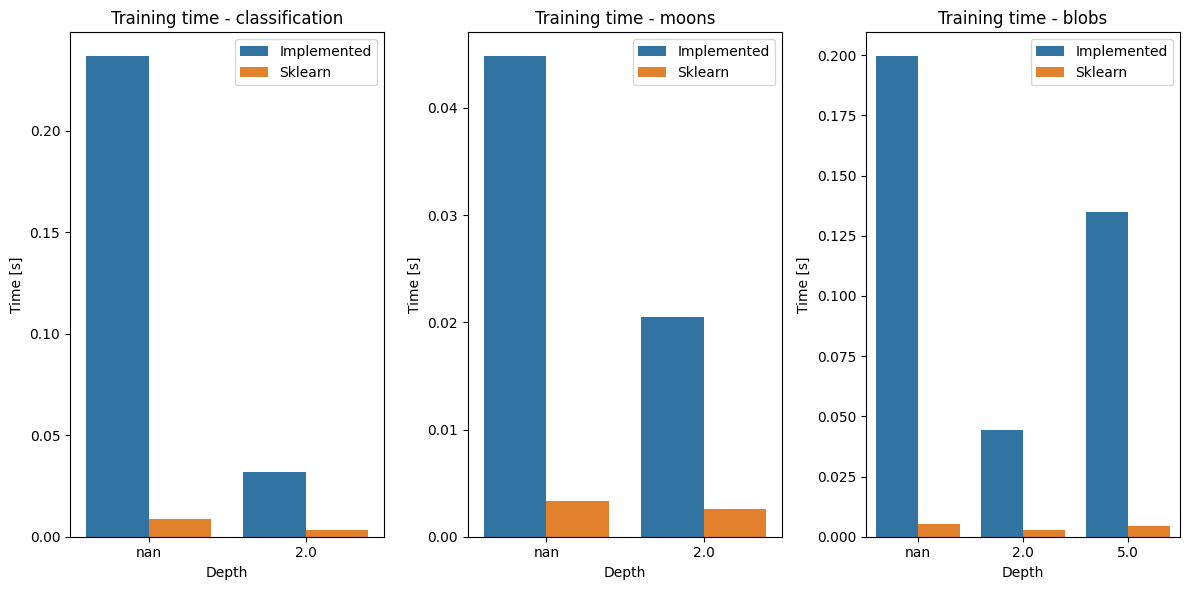

In [72]:
plt.figure(figsize=(12, 6))
for ds_name in sorted(times_df['dataset'].unique()):
    plt.subplot(1, 3, list(times_df['dataset'].unique()).index(ds_name) + 1)
    
    ds_times = times_df[times_df['dataset'] == ds_name]
    
    plot_data = ds_times.copy()
    plot_data['depth'] = plot_data['depth'].apply(lambda x: str(x))
    
    sns.barplot(x='depth', y='time', hue='type', data=plot_data)
    
    plt.title(f'Training time - {ds_name}')
    plt.xlabel('Depth')
    plt.ylabel('Time [s]')
    plt.legend()
    
plt.tight_layout()
plt.show()

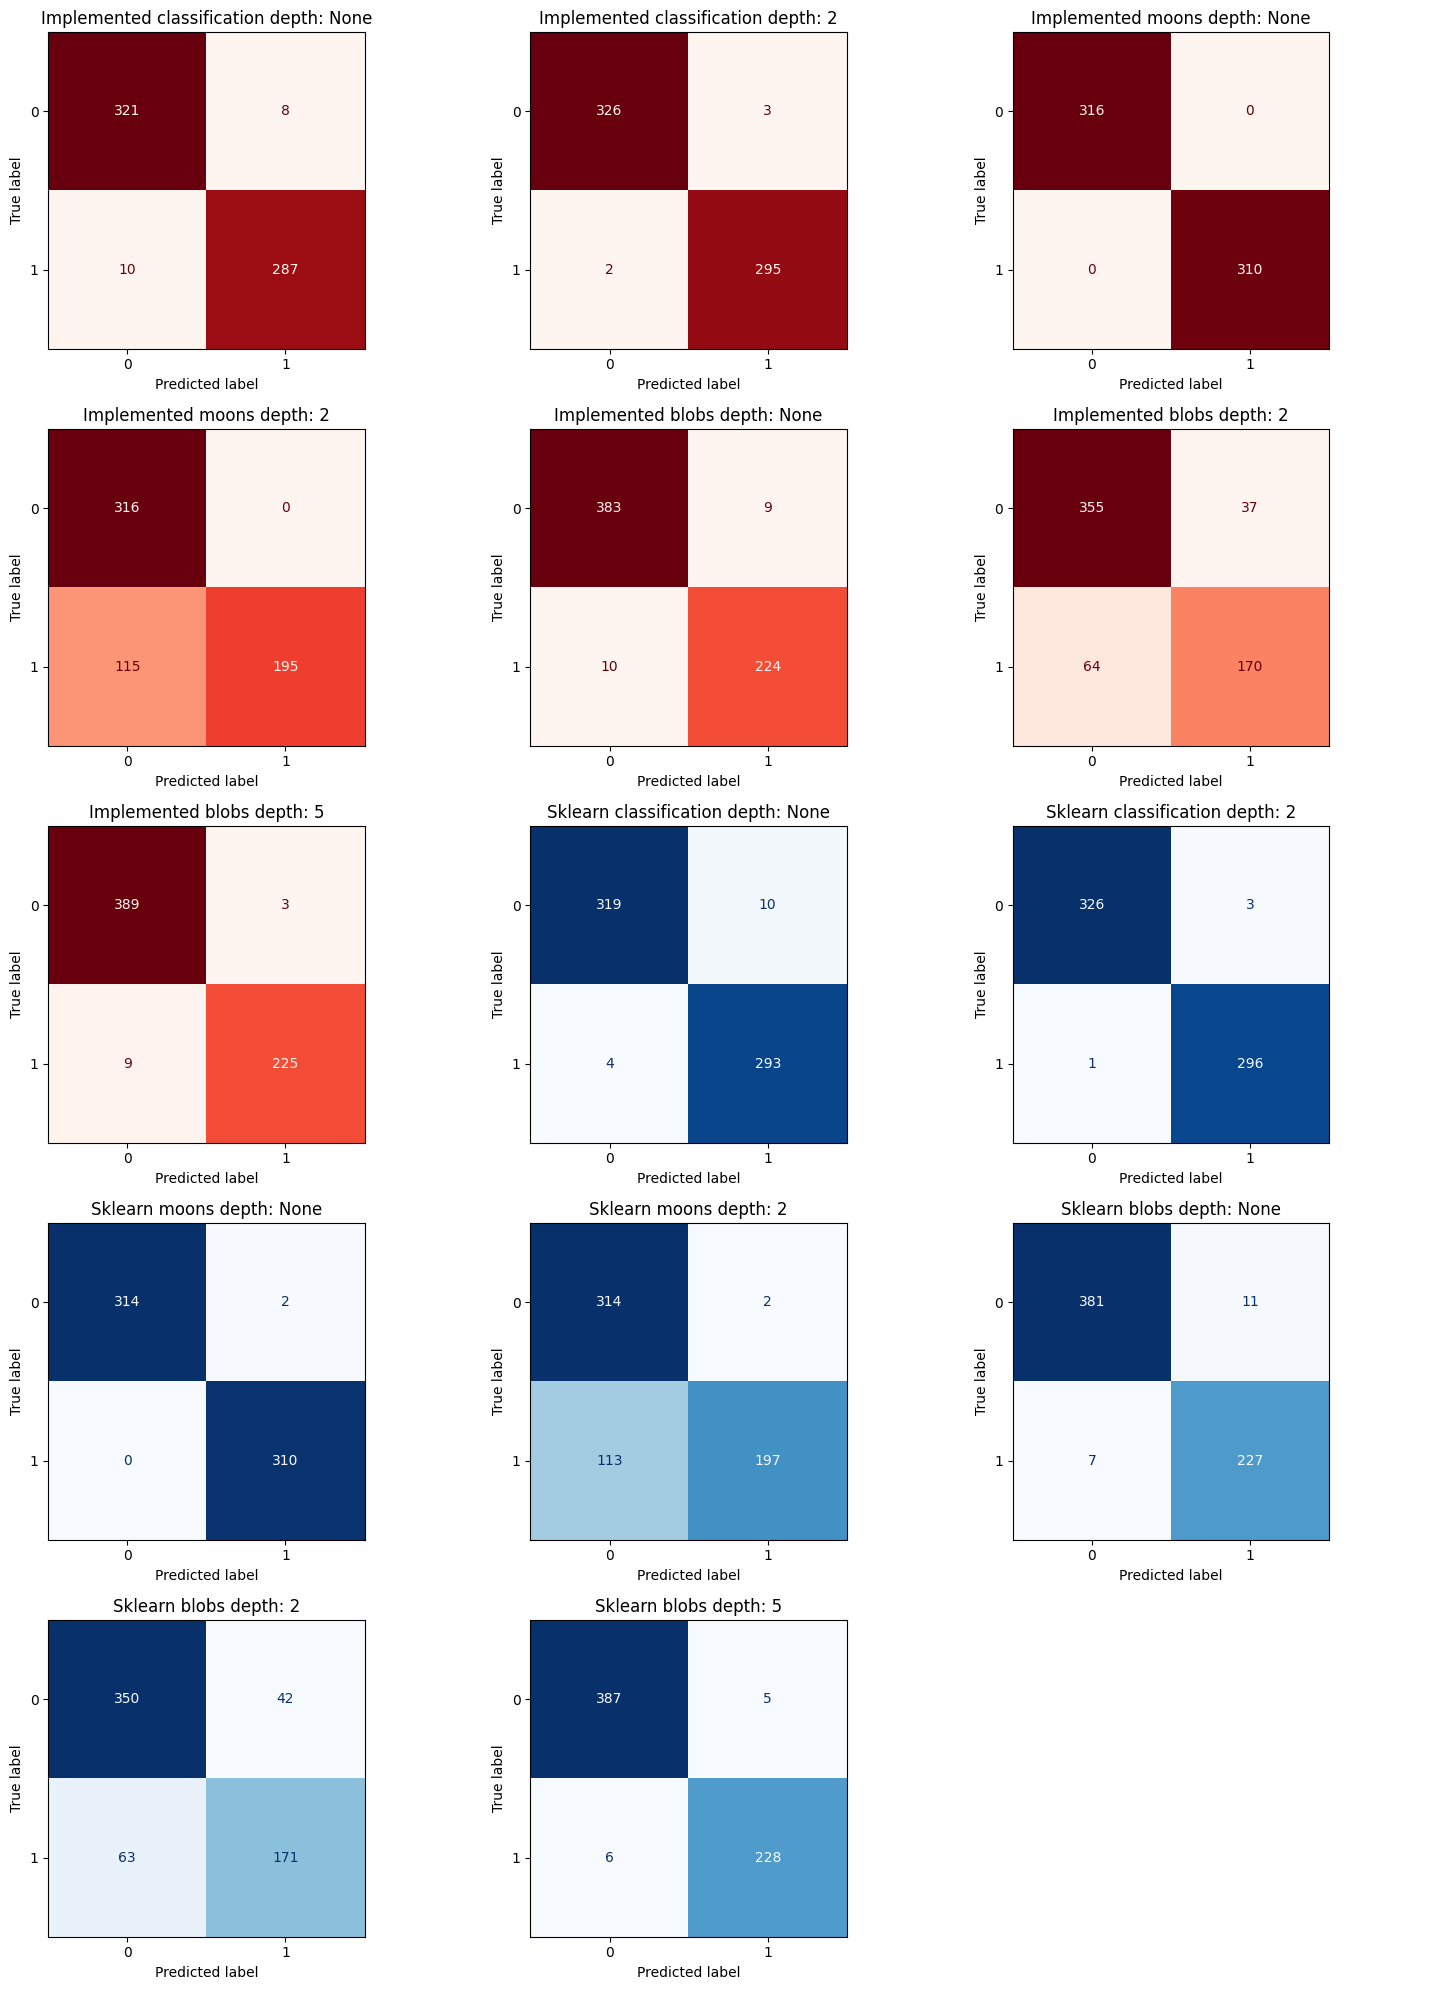

In [74]:
cms = {}
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()
for i, row in enumerate(cm_df):
    if row['type'] == "Sklearn":
        color_map = "Blues"
    else:
        color_map = "Reds"
    cm = confusion_matrix(row['y_true'], row['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap=color_map, colorbar=False)
    cm_title = f"{row['type']} {row['dataset']} depth: {str(row['depth'])}"
    axes[i].set_title(cm_title)
    cms[cm_title] = cm

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [75]:
stats_df = pd.DataFrame(columns=['dataset', 'type', 'depth', 'specificity', 'sensitivity'])

for cm_name, cm_matrix in cms.items():
    parts = cm_name.split()
    model_type = parts[0] 
    dataset = parts[1]
    depth = parts[3]
    
    tn, fp, fn, tp = cm_matrix.ravel()
    specificity = tn / (tn+fp) if (tn+fp) > 0 else 0
    sensitivity = tp / (tp+fn) if (tp+fn) > 0 else 0

    stats_df.loc[len(stats_df)] = [model_type, dataset, depth, specificity, sensitivity]
    
stats_df = stats_df.round(3)
stats_df

,dataset,type,depth,specificity,sensitivity
0,Implemented,classification,None,0.976,0.966
1,Implemented,classification,2,0.991,0.993
2,Implemented,moons,None,1.000,1.000
3,Implemented,moons,2,1.000,0.629
4,Implemented,blobs,None,0.977,0.957
5,Implemented,blobs,2,0.906,0.726
6,Implemented,blobs,5,0.992,0.962
7,Sklearn,classification,None,0.970,0.987
8,Sklearn,classification,2,0.991,0.997
9,Sklearn,moons,None,0.994,1.000


In [76]:
roc_df = pd.DataFrame(roc_df)
roc_df

,type,dataset,depth,y_true,y_score
0,Implemented,classification,NaN,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, ...","[[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0..."
1,Implemented,classification,2.0,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, ...","[[0.9900552486187846, 0.009944751381215469], [..."
2,Implemented,moons,NaN,"[1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, ...","[[0.0, 1.0], [1.0, 0.0], [0.0, 1.0], [1.0, 0.0..."
3,Implemented,moons,2.0,"[1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, ...","[[0.0, 1.0], [1.0, 0.0], [0.5070866141732283, ..."
4,Implemented,blobs,NaN,"[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, ...","[[0.0, 1.0], [1.0, 0.0], [1.0, 0.0], [0.0, 1.0..."
5,Implemented,blobs,2.0,"[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, ...","[[0.3244444444444444, 0.6755555555555556], [0...."
6,Implemented,blobs,5.0,"[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, ...","[[0.0, 1.0], [1.0, 0.0], [1.0, 0.0], [0.0, 1.0..."
7,Sklearn,classification,NaN,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, ...","[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."
8,Sklearn,classification,2.0,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, ...","[0.009933774834437087, 0.9924731182795699, 0.0..."
9,Sklearn,moons,NaN,"[1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ..."


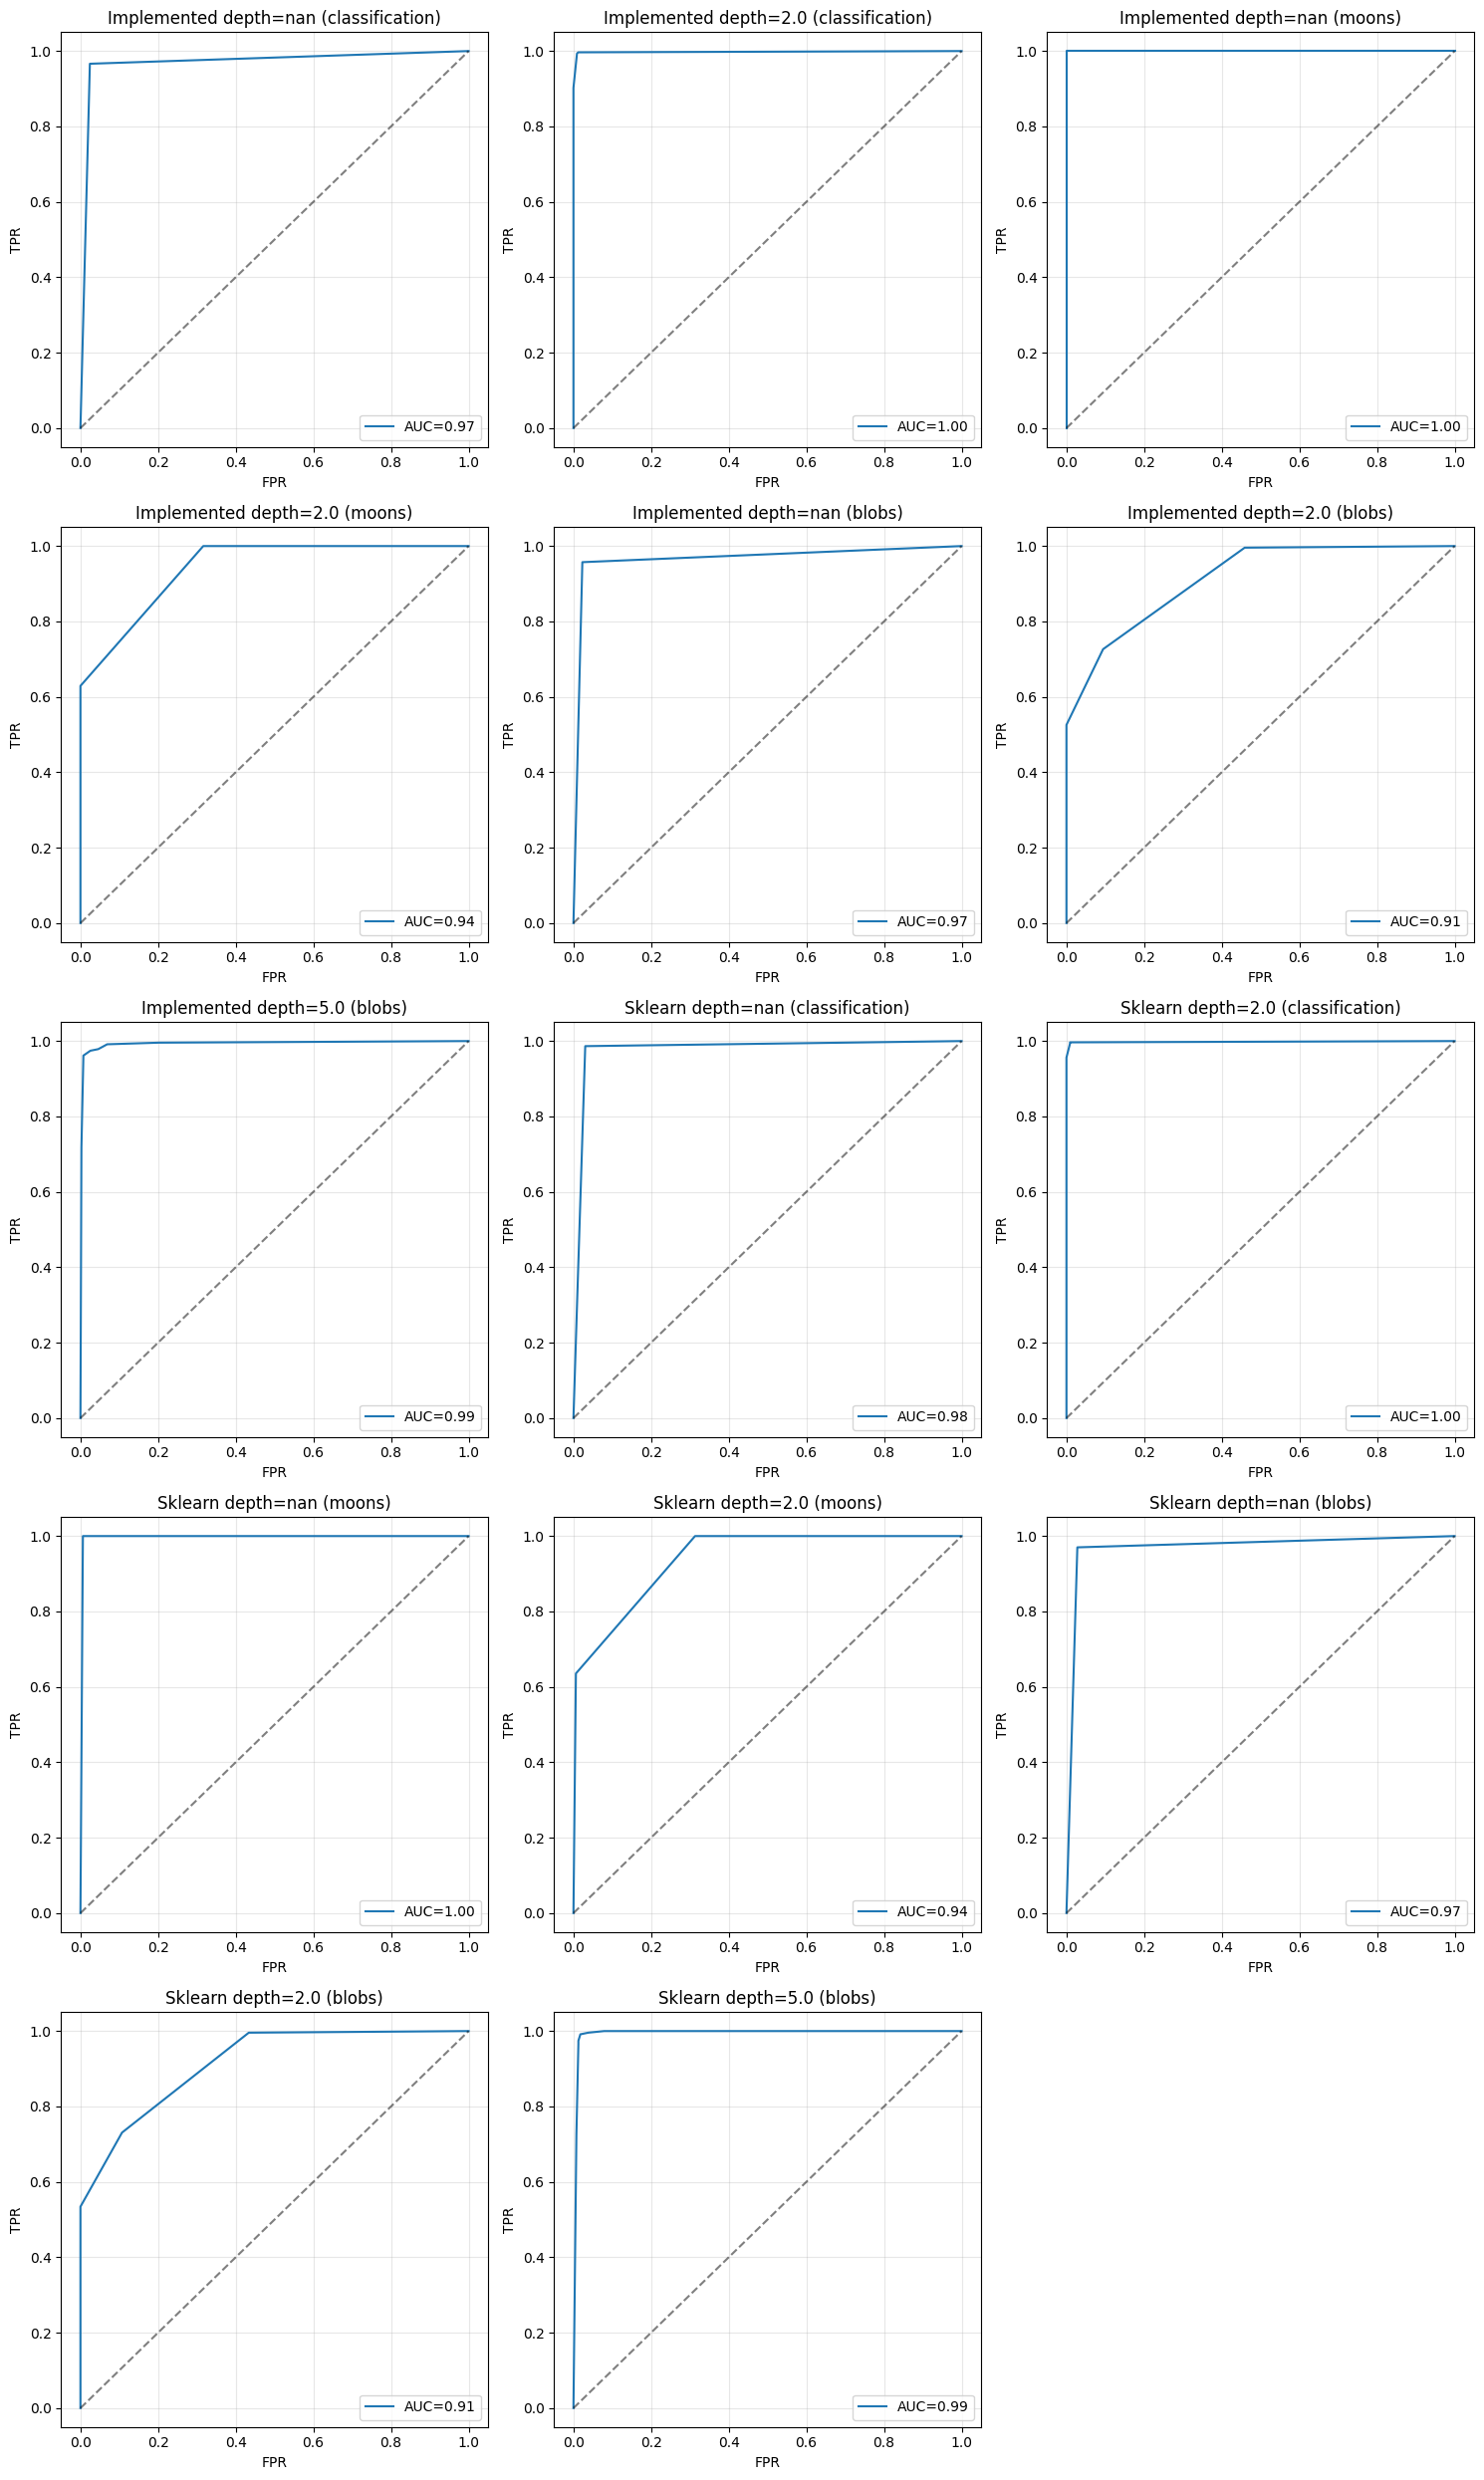

In [78]:
n_plots = len(roc_df)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (_, row) in enumerate(roc_df.iterrows()):
    if i >= len(axes):
        break
        
    model_type = row['type']
    depth = row['depth']
    dataset = row['dataset']
    y_true = row['y_true']
    y_score = row['y_score'][:,1] if len(row['y_score'].shape) > 1 else row['y_score']
    
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].set_title(f"{model_type} depth={depth} ({dataset})")
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

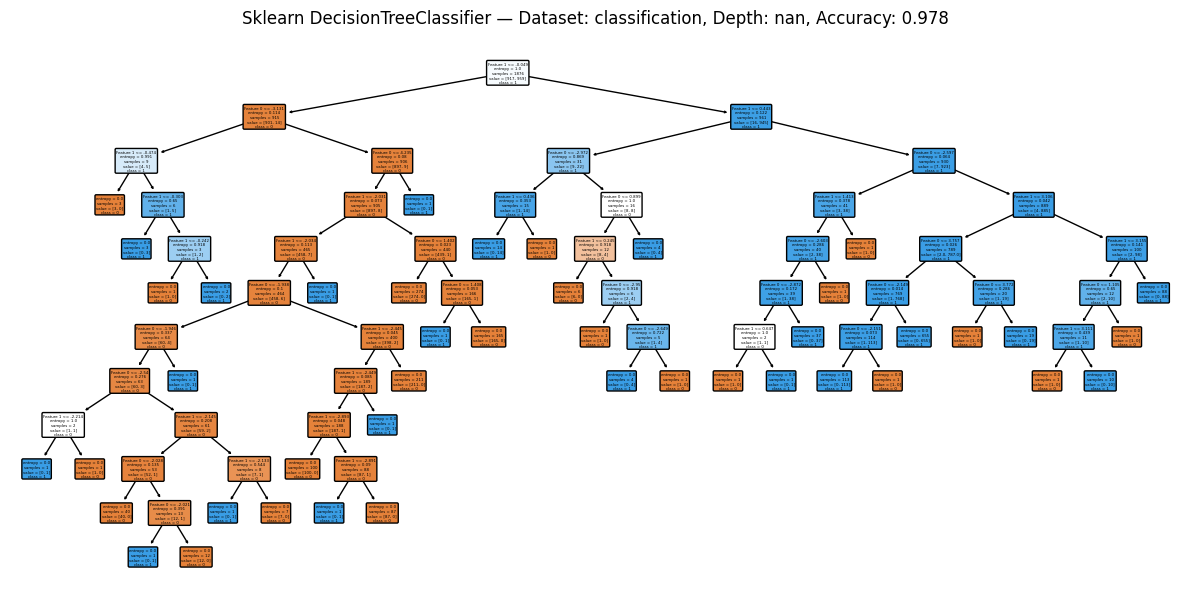

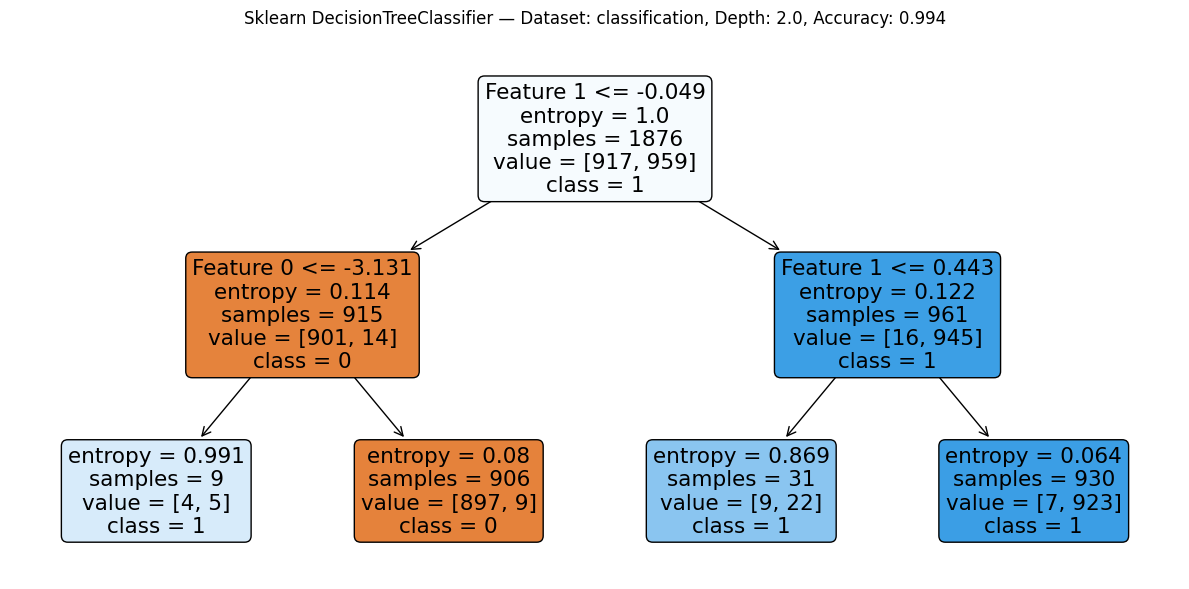

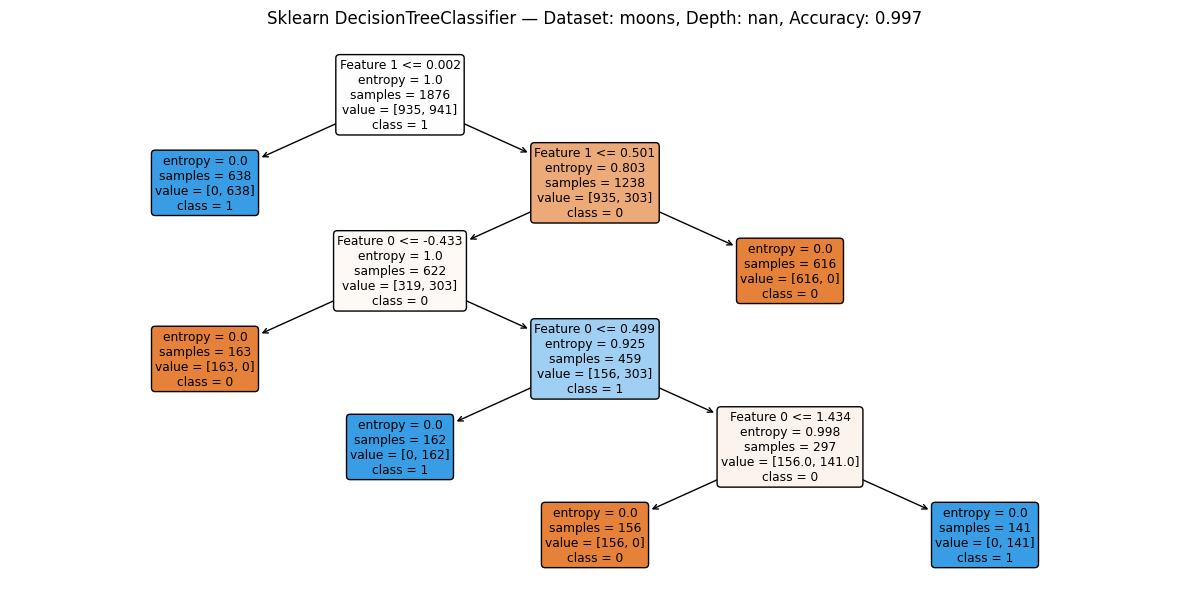

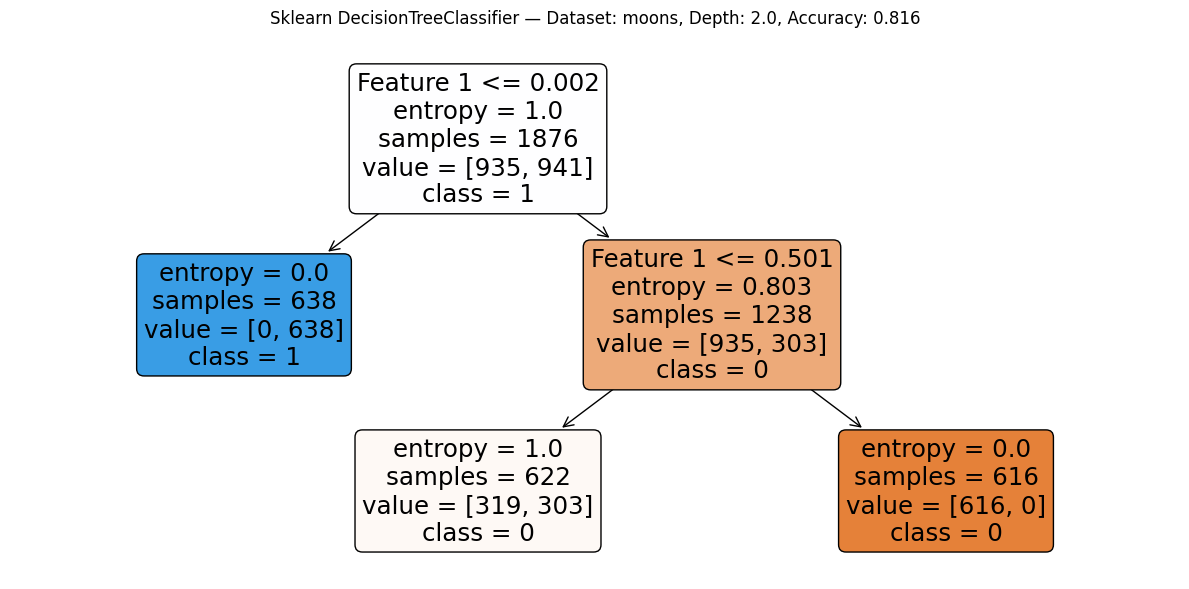

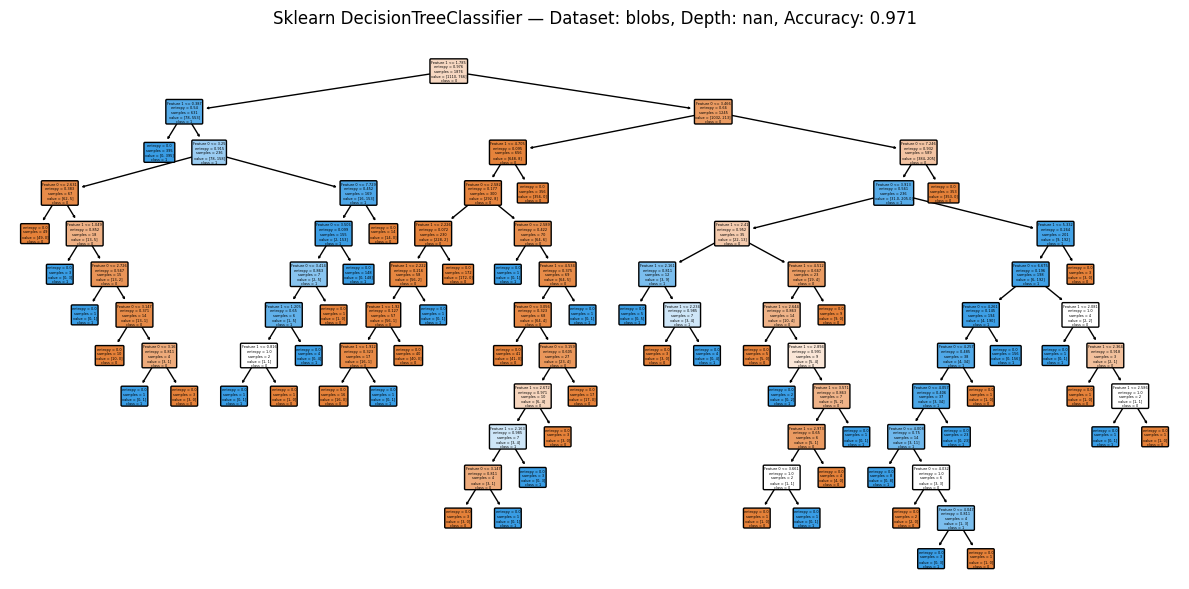

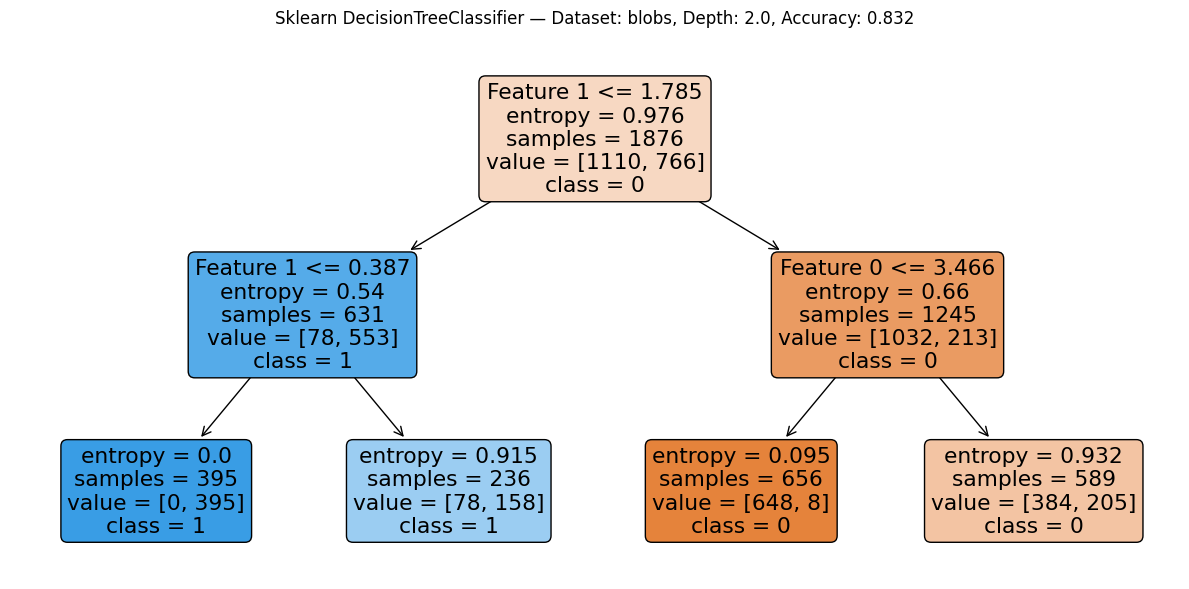

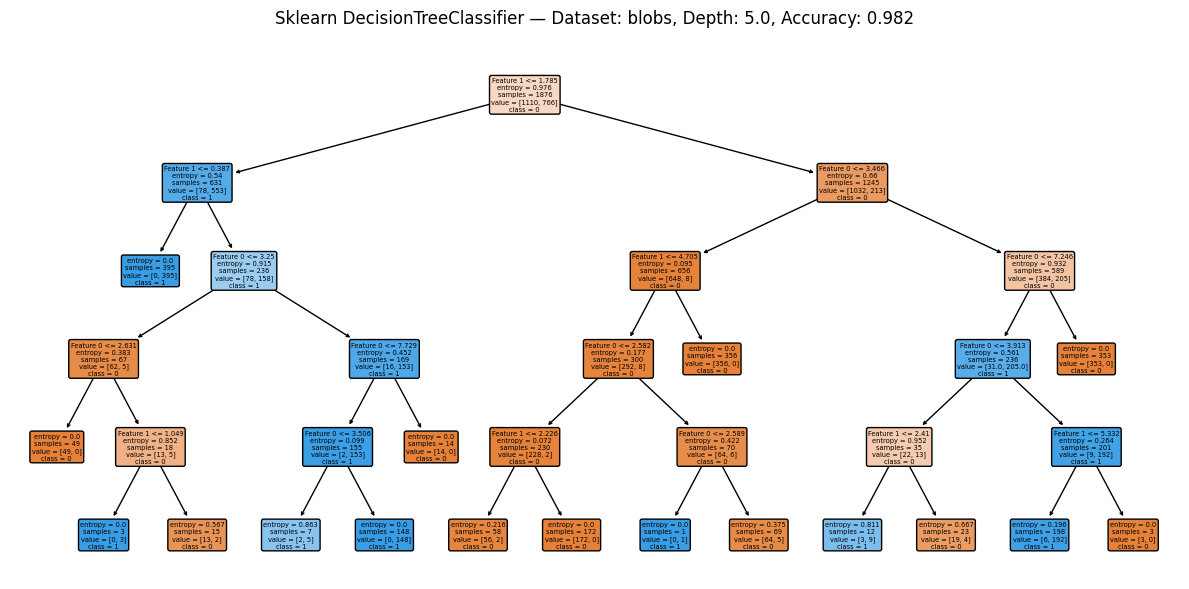

In [79]:
for _, result in results_df.iterrows():
    ds_name = result['dataset']
    depth = result['depth']
    model = result['model']
    _, _, X_te, y_te = datasets[ds_name]
    
    title = f"Sklearn DecisionTreeClassifier — Dataset: {ds_name}, Depth: {depth}, Accuracy: {result['accuracy']:.3f}"
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    plot_tree(
        model,
        ax=ax,
        filled=True,
        rounded=True,
        feature_names=[f"Feature {i}" for i in range(X_te.shape[1])],
        class_names=[str(c) for c in np.unique(y_te)]
    )
    
    ax.set_title(title, pad=20)
    
    plt.tight_layout()
    plt.show()

# Dataset HTRU2

High Time Resolution Universe Survey 

1. Mean of the integrated profile.
2. Standard deviation of the integrated profile.
3. Excess kurtosis of the integrated profile.
4. Skewness of the integrated profile.
5. Mean of the DM-SNR curve.
6. Standard deviation of the DM-SNR curve.
7. Excess kurtosis of the DM-SNR curve.
8. Skewness of the DM-SNR curve.
9. Class

In [417]:
data = pd.read_csv('./htru2/HTRU_2.csv', header=None)
data

,0,1,2,3,4,5,6,7,8
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


In [418]:
columns = ["Profile_mean", "Profile_stdev", "Profile_skewness", "Profile_kurtosis", "DM_mean", "DM_stdev", "DM_skewness", "DM_kurtosis", "Class"]
data.columns = columns
data

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,Class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


In [419]:
X, y = data.drop(columns=['Class']), data['Class']
X.shape, y.shape

((17898, 8), (17898,))

In [420]:
X

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306
...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910


Data preprocessing

In [421]:
X.isna().sum()

Profile_mean        0
Profile_stdev       0
Profile_skewness    0
Profile_kurtosis    0
DM_mean             0
DM_stdev            0
DM_skewness         0
DM_kurtosis         0
dtype: int64

In [422]:
y.isna().sum()

0

In [423]:
y.value_counts()

Class
0    16259
1     1639
Name: count, dtype: int64

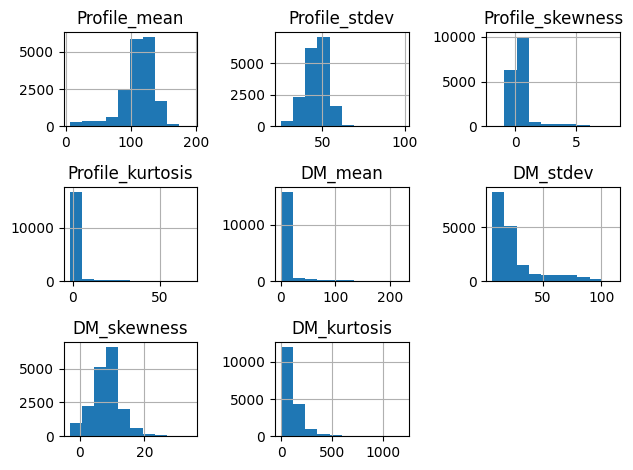

In [424]:
X.hist()
plt.tight_layout()
plt.show()

In [425]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=259202, stratify=y)

In [426]:
X_train.min()

Profile_mean         5.812500
Profile_stdev       24.772042
Profile_skewness    -1.876011
Profile_kurtosis    -1.781888
DM_mean              0.213211
DM_stdev             7.370432
DM_skewness         -3.139270
DM_kurtosis         -1.976976
dtype: float64

In [427]:
# normalization
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [428]:
X_train_normalized.min(), X_train_normalized.max()

(0.0, 1.0000000000000002)

In [374]:
parameters = {'criterion':('gini', 'entropy', 'log_loss'), 
              'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
              'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
dtc = DecisionTreeClassifier()
clf = GridSearchCV(dtc, parameters)
clf.fit(X_train_normalized, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ('gini', 'entropy', 'log_loss'),
                         'max_depth': [None, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]})

In [375]:
cv_results_df = pd.DataFrame(clf.cv_results_)
cv_results_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
537,0.058924,0.000753,0.001374,0.000469,gini,5,10,8,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.977654,0.977654,0.982868,0.980999,0.978763,0.979587,0.002045,1
536,0.059233,0.003349,0.001219,0.000394,gini,5,10,7,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.977654,0.977654,0.982868,0.980999,0.978763,0.979587,0.002045,1
539,0.057801,0.000588,0.001016,0.000041,gini,5,10,10,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.977654,0.976536,0.982868,0.980999,0.978763,0.979364,0.002290,3
538,0.057536,0.000659,0.001210,0.000388,gini,5,10,9,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.977654,0.976536,0.982868,0.980999,0.978763,0.979364,0.002290,3
535,0.057907,0.001281,0.001180,0.000362,gini,5,10,6,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.977654,0.976536,0.982868,0.980999,0.978763,0.979364,0.002290,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,0.160590,0.015808,0.001601,0.000490,entropy,None,1,5,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.962384,0.961639,0.969088,0.970566,0.965723,0.965880,0.003535,2966
992,0.134019,0.007543,0.001038,0.000044,entropy,None,1,4,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.963128,0.961266,0.966853,0.969449,0.966841,0.965507,0.002925,2967
991,0.146686,0.016401,0.001981,0.000069,entropy,None,1,3,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.965363,0.960149,0.968715,0.969821,0.963487,0.965507,0.003513,2968
990,0.153517,0.012770,0.001223,0.000442,entropy,None,1,2,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.966480,0.961639,0.968343,0.967958,0.963115,0.965507,0.002671,2969


In [376]:
# best params
cv_results_df.sort_values(by=['rank_test_score'])['params'][0]

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [377]:
y_pred = clf.predict(X_test_normalized)
acc = accuracy_score(y_test, y_pred)
print(f"For the best params in GridSearchCV accuracy: {acc}")

For the best params in GridSearchCV accuracy: 0.9794413407821229


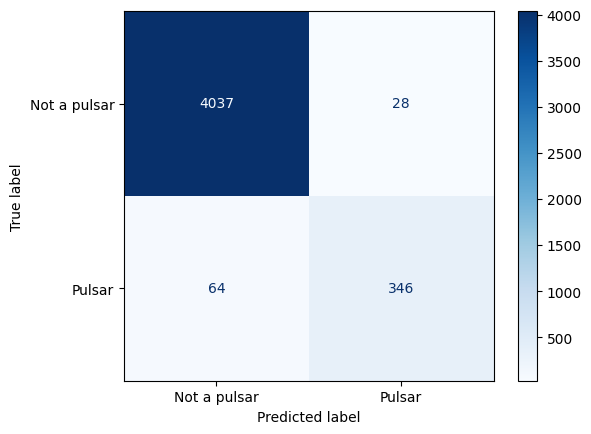

In [378]:
cm = confusion_matrix(y_test, y_pred, labels = clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not a pulsar", "Pulsar"])
disp.plot(cmap='Blues')
plt.show()

In [437]:
depths = [None] + list(range(1, 11))
count = 10
results = []
for depth in depths:
        time_skl = 0
        time_impl = 0
        acc_skl = 0
        acc_impl = 0
        for _ in range(count):
                clf_skl = DecisionTreeClassifier(max_depth=depth)
                clf_skl.fit(X_train_normalized, y_train)
                
                start_time = time.time()
                y_pred = clf_skl.predict(X_test_normalized)
                time_s = time.time() - start_time
                
                acc_s = accuracy_score(y_test, y_pred)


                clf_impl = DecisionTree(max_depth=depth)
                clf_impl.fit(X_train_normalized, y_train.values)
                
                start_time = time.time()
                y_pred = clf_impl.predict(X_test_normalized)
                time_i = time.time() - start_time
                
                acc_i = accuracy_score(y_test.values, y_pred)
                
                time_skl += time_s
                time_impl += time_i
                acc_skl += acc_s
                acc_impl += acc_i
        
        results.append({
                'model': 'sklearn',
                'depth': depth,
                'inference time': time_skl/count,
                'accuracy': acc_skl/count
        })
        results.append({
                'model': 'implemented',
                'depth': depth,
                'inference time': time_impl/count,
                'accuracy': acc_impl/count
        })

In [438]:
res = pd.DataFrame(results)
res.sort_values(by=['accuracy'], ascending=False)

,model,depth,inference time,accuracy
11,implemented,5.0,0.004160,0.980335
13,implemented,6.0,0.005160,0.980335
17,implemented,8.0,0.006478,0.979665
10,sklearn,5.0,0.000701,0.979486
7,implemented,3.0,0.003209,0.979441
15,implemented,7.0,0.006174,0.978994
9,implemented,4.0,0.003652,0.978994
6,sklearn,3.0,0.000501,0.978771
4,sklearn,2.0,0.000100,0.978771
2,sklearn,1.0,0.000298,0.978771


### Is it justified to optimize training and evaluation time by searching for the optimal tree depth when choosing a target for the first probe tasked with closely studying a pulsar?


While we should not prioritize training speed over accuracy - especially in missions where the cost of error is immense, searching for the optimal tree depth is not a shortcut for speed, but a necessary step toward building a reliable model. Properly tuning the model (including tree depth) is essential for ensuring that the final classification decision is as trustworthy as possible.

We can see in the example above that the best accuracy is not for unlimited depth - therefore the model is not overfitted.

Similarly, when traveling for years, time is not the limiting factor — we have plenty of it. So, it's reasonable to invest some of that time in searching for the optimal tree depth.